# Once things are generated - what is selecting them like?

This version based on KDE-derived densities only!

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters.util import position_to_max_galaxy_distance

from hr_selection_function import HR24SelectionFunction, NStarsPredictor, GaiaDensityEstimator

from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde, multivariate_normal

from astropy.coordinates import SkyCoord
from astropy import units as u


In [2]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

## Helper functions

In [3]:
def measure_cluster_density(
    cluster_info,
    members,
    magnitude_limits,
    use_combined=True,
    missions=("gaianir-l", "gaianir-m", "gaia_dr5", "gaia_dr4", "gaia_dr3"),
):
    # Add DR3 (DR4 but rescaled)
    members = add_gaia_dr3_uncertainties_based_on_sampling(members)
    members["gaia_dr3"] = members["gaia_dr4"]

    # Cycle over every mission, calculating stuffs
    result = dict()
    for mission in missions:
        maglim = magnitude_limits[mission]

        subsample = members.loc[
            (members[mission]) & (members[maglim["band"]] < maglim["limit"])
        ]
        key_astrometry = mission
        if use_combined and "gaianir" in mission:
            key_astrometry = mission + "_combined"

        result[f"n_stars_{mission}"] = len(subsample)
        if len(subsample) > 5:
            (
                result[f"rho_position_{mission}"],
                result[f"rho_pm_{mission}"],
                result[f"rho_parallax_{mission}"],
                result[f"rho_astrometric_{mission}"],
                result[f"rho_full_{mission}"],
            ) = _calculate_cluster_density(
                subsample["l"],
                subsample["b"],
                subsample[f"pmra_{key_astrometry}"],
                subsample[f"pmdec_{key_astrometry}"],
                subsample[f"parallax_{key_astrometry}"],
                cluster_info,
            )
        else:
            (
                result[f"rho_position_{mission}"],
                result[f"rho_pm_{mission}"],
                result[f"rho_parallax_{mission}"],
                result[f"rho_astrometric_{mission}"],
                result[f"rho_full_{mission}"],
            ) = 0.0, 0.0, 0.0, 0.0, 0.0

    return result


def _calculate_cluster_density(
    l,
    b,
    pmra,
    pmdec,
    parallax,
    cluster_info,
):
    """Performs successive KDEs to estimate the peak density of a cluster."""
    # Todo this code fails at l=0 - probably not an issue, but bear in mind
    if np.any(l > 270) and np.any(l < 90):
        raise ValueError("Coordinate discontinuities are not supported.")

    n_points = len(l)

    positions = np.vstack((l, b))
    proper_motions = np.vstack((pmra, pmdec))

    kde_pos = gaussian_kde(positions)
    kde_pm = gaussian_kde(proper_motions)
    kde_parallax = gaussian_kde(parallax)
    kde_astro = gaussian_kde(np.vstack((pmra, pmdec, parallax)))
    kde_full = gaussian_kde(np.vstack((l, b, pmra, pmdec, parallax)))

    return (
        n_points * kde_pos((cluster_info["l"], cluster_info["b"]))[0],
        n_points * kde_pm((cluster_info["pmra"], cluster_info["pmdec"]))[0],
        n_points * kde_parallax(cluster_info["parallax"])[0],
        n_points
        * kde_astro(
            (cluster_info["pmra"], cluster_info["pmdec"], cluster_info["parallax"])
        )[0],
        n_points
        * kde_full(
            (
                cluster_info["l"],
                cluster_info["b"],
                cluster_info["pmra"],
                cluster_info["pmdec"],
                cluster_info["parallax"],
            )
        )[0],
    )


def measure_region_density(
    cluster_locations,
    region,
    region_area,
    magnitude_limits,
    stars_in_sample_desired: int = 50,
    stars_in_sample_minimum: int = 5,
    stars_in_sample_region_scale: float | int = 3,
    parallax_move_amount=0.1,
    missions=("gaianir-l", "gaianir-m", "gaia_dr5", "gaia_dr4", "gaia_dr3"),
    use_combined: bool = True,
    bandwidth_method: str = "scott",
):
    for mission in missions:
        maglim = magnitude_limits[mission]
        key_out = mission
        key_proper_motion = mission
        key_parallax = mission

        if use_combined and "gaianir" in mission:
            key_proper_motion = key_proper_motion + "_combined"

        key_crowding = f"uncrowded_{mission.replace('_dr4', '').replace('_dr5', '').replace('_dr3', '')}"  # todo this is ugly af
        region_valid = region.loc[
            (region[key_crowding])
            & (
                region[maglim["band"].replace("g_effective_gaia", "gaia_dr3_g")]
                < maglim["limit"]
            )
        ]
        # if len(region_valid) < minimum_stars_in_sample:
        #     raise ValueError(
        #         f"valid region contains too few stars {len(region_valid)} - consider "
        #         "increasing minimum_stars_in_sample"
        #     )

        this_minimum_stars = np.clip(
            len(region_valid) / stars_in_sample_region_scale,
            stars_in_sample_minimum,
            stars_in_sample_desired,
        )

        # Iterate over each parallax/cluster pm and identify its data density
        for i_row, a_row in cluster_locations.iterrows():
            # Get a sample of stars
            parallax_var = parallax_move_amount
            subsample = []
            while len(subsample) < this_minimum_stars:
                subsample = region_valid.loc[
                    (
                        region_valid[f"parallax_{key_parallax}"]
                        > a_row["parallax"] - parallax_var
                    )
                    & (
                        region_valid[f"parallax_{key_parallax}"]
                        < a_row["parallax"] + parallax_var
                    )
                ]
                parallax_var *= 2

            # Do a KDE to estimate the density at this point
            kde = gaussian_kde(
                subsample[[f"pmra_{key_proper_motion}", f"pmdec_{key_proper_motion}"]]
                .to_numpy()
                .T,
                bw_method=bandwidth_method,
            )
            background_density = kde([a_row["pmra"], a_row["pmdec"]])

            # Do a multivariate normal to estimate the density at this point
            # X = subsample[[f"pmra_{key_proper_motion}", f"pmdec_{key_proper_motion}"]]
            # mean = np.mean(X, axis=0)
            # cov = np.cov(X.T)
            # single_multivariate = multivariate_normal(mean, cov)
            # background_density = single_multivariate.pdf(
            #     [a_row["pmra"], a_row["pmdec"]]
            # )

            # Scale everything based on scale factors so that rho_data
            # is correct - i.e., n_stars mas^{-3} yr^{2} field^{-1}
            width = parallax_var * 2
            cluster_locations.loc[i_row, f"rho_data_pm_{key_out}"] = (
                len(subsample)
                * background_density
                / width  # Parallax width
                / region_area  # Area of underlying simulated region
                # * 30.21  # HR23 clustering field area
            )

            cluster_locations.loc[i_row, f"rho_data_position_{key_out}"] = (
                len(region_valid) / region_area
            )

            # Also record the number of stars, just out of curiosity
            cluster_locations.loc[i_row, f"n_stars_for_rho_data_{key_out}"] = len(
                subsample
            )

    return cluster_locations


def add_gaia_dr3_uncertainties_based_on_sampling(region, seed=None):
    """Adds approximate Gaia DR3 observations to a region, based on back-extrapolating
    uncertainties from Gaia DR4.
    """
    # Make errors based on scale factors
    parallax_scale = np.sqrt(66 / 34)
    pm_scale = 66 / 34 * parallax_scale

    region["pmra_error_gaia_dr3"] = region["pmra_error_gaia_dr4"] * pm_scale
    region["pmdec_error_gaia_dr3"] = region["pmdec_error_gaia_dr4"] * pm_scale
    region["parallax_error_gaia_dr3"] = (
        region["parallax_error_gaia_dr4"] * parallax_scale
    )

    # Resample based on scale factors
    rng = np.random.default_rng(seed)

    region["pmra_gaia_dr3"] = rng.normal(
        loc=region["pmra_true"], scale=region["pmra_error_gaia_dr4"]
    )
    region["pmdec_gaia_dr3"] = rng.normal(
        loc=region["pmdec_true"], scale=region["pmdec_error_gaia_dr4"]
    )
    region["parallax_gaia_dr3"] = rng.normal(
        loc=region["parallax_true"], scale=region["parallax_error_gaia_dr4"]
    )

    return region


## Measure densities

In [4]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

coords = (
    SkyCoord(
        l=simulated_clusters["l"].to_numpy() * u.deg,
        b=simulated_clusters["b"].to_numpy() * u.deg,
        distance=simulated_clusters["distance"].to_numpy() * u.pc,
        frame="galactic",
    )
    .transform_to("galactocentric")
    .represent_as("cylindrical")
)
simulated_clusters["r_gc"] = coords.rho.to(u.pc).value
simulated_clusters["parallax"] = 1000 / simulated_clusters['distance']
# simulated_clusters = simulated_clusters.query("r_gc < 20000")

In [ ]:
magnitude_limits = {
    "gaianir-l": {"band": "gaianir_n", "limit": 20.5},
    "gaianir-m": {"band": "gaianir_n", "limit": 20},
    "gaia_dr5": {"band": "g_effective_gaia", "limit": 19},
    "gaia_dr4": {"band": "g_effective_gaia", "limit": 18.5},
    "gaia_dr3": {"band": "g_effective_gaia", "limit": 18},
}

In [28]:
cluster_density_df = {}
for i_row, a_row in simulated_clusters.iterrows():
    print(f"\r{i_row + 1} of {len(simulated_clusters)}", end="")
    members = pd.read_parquet(RESULTS_DIRECTORY / a_row["path"])
    cluster_density_df[i_row] = measure_cluster_density(
        a_row, members, magnitude_limits
    )

cluster_density_df = pd.DataFrame.from_dict(cluster_density_df, orient="index")

2832 of 2832

In [29]:
simulated_clusters_with_density = simulated_clusters.join(cluster_density_df)

In [30]:
simulated_clusters_with_density.keys()

Index(['cluster', 'l', 'b', 'path', 'path_region', 'distance', 'extinction',
       'differential_extinction', 'ra', 'dec', 'pmra', 'pmdec',
       'radial_velocity', 'mass', 'log_age', 'metallicity', 'r_core',
       'r_tidal', 'virial_ratio', 'r_gc', 'parallax', 'n_stars_gaianir-l',
       'rho_position_gaianir-l', 'rho_pm_gaianir-l', 'rho_parallax_gaianir-l',
       'rho_astrometric_gaianir-l', 'rho_full_gaianir-l', 'n_stars_gaianir-m',
       'rho_position_gaianir-m', 'rho_pm_gaianir-m', 'rho_parallax_gaianir-m',
       'rho_astrometric_gaianir-m', 'rho_full_gaianir-m', 'n_stars_gaia_dr5',
       'rho_position_gaia_dr5', 'rho_pm_gaia_dr5', 'rho_parallax_gaia_dr5',
       'rho_astrometric_gaia_dr5', 'rho_full_gaia_dr5', 'n_stars_gaia_dr4',
       'rho_position_gaia_dr4', 'rho_pm_gaia_dr4', 'rho_parallax_gaia_dr4',
       'rho_astrometric_gaia_dr4', 'rho_full_gaia_dr4', 'n_stars_gaia_dr3',
       'rho_position_gaia_dr3', 'rho_pm_gaia_dr3', 'rho_parallax_gaia_dr3',
       'rho_astrome

[Text(0.5, 1.0, 'n_stars')]

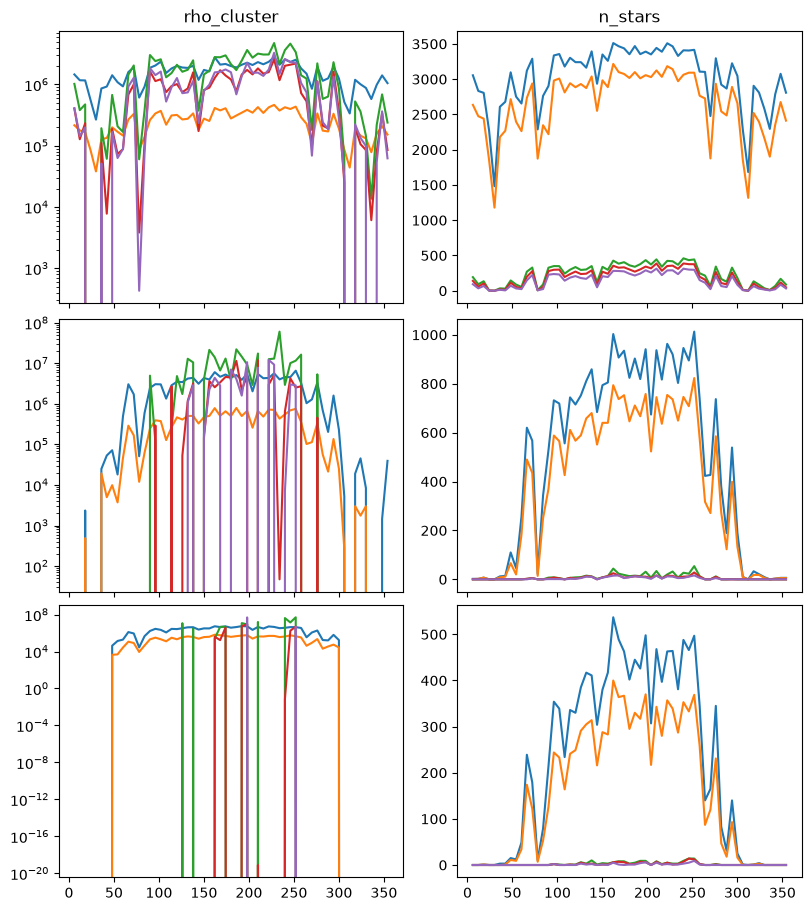

In [31]:
cluster = "berkeley_29"
distances = [2000, 10000, 20000]

fig, ax = plt.subplots(
    nrows=len(distances),
    ncols=2,
    figsize=(8, 3 * len(distances)),
    layout="constrained",
    sharex=True,
)

for an_ax, distance in zip(ax, distances):
    subsample = simulated_clusters_with_density.query(
        f"cluster=='{cluster}' and distance=={distance}"
    )
    for a_mission in magnitude_limits:
        an_ax[0].plot(
            subsample["l"], subsample[f"rho_full_{a_mission}"], label=a_mission
        )
        an_ax[1].plot(subsample["l"], subsample[f"n_stars_{a_mission}"])

    an_ax[0].set(yscale="log")
    # an_ax[1].set(yscale="log")

ax[0, 0].set(title="rho_cluster")
ax[0, 1].set(title="n_stars")

In [32]:
unique_locations = simulated_clusters[
    ["l", "b", "distance", "pmra", "pmdec", "path_region"]
].drop_duplicates().sort_values(["l", "b", "distance"]).reset_index(drop=True)

unique_locations['parallax'] = 1000 / unique_locations['distance']

In [33]:
region_density_df = []
paths = unique_locations["path_region"].unique()
for i, short_path_region in enumerate(paths):
    print(f"\r{i + 1} of {len(paths)}", end="")

    valid_clusters = unique_locations.query(f"path_region=='{short_path_region}'")

    path_region = RESULTS_DIRECTORY / short_path_region
    path_metadata = path_region.parent / (path_region.stem + "_metadata.pickle")
    region = pd.read_parquet(path_region)
    region = add_gaia_dr3_uncertainties_based_on_sampling(region)

    with open(RESULTS_DIRECTORY / path_metadata, "rb") as file:
        region_area = pickle.load(file)["area"]

    region_density_df.append(
        measure_region_density(
            valid_clusters,
            region,
            region_area,
            magnitude_limits,
        )
    )

region_density_df = pd.concat(region_density_df, ignore_index=True).drop(
    columns=["path_region", "parallax"]
)

59 of 59

In [34]:
simulated_clusters_full = simulated_clusters_with_density.merge(
    region_density_df, on=["l", "b", "distance", "pmra", "pmdec"], how="left"
)

## Add empirical results from DR3

In [35]:
n_stars_predictor = NStarsPredictor(models=100)
density_estimator = GaiaDensityEstimator()
# simulated_clusters_with_density

In [36]:
coords = SkyCoord(
    ra=simulated_clusters_full["ra"].to_numpy() * u.deg,
    dec=simulated_clusters_full["dec"].to_numpy() * u.deg,
    pm_ra_cosdec=simulated_clusters_full["pmra"].to_numpy() * u.mas / u.yr,
    pm_dec=simulated_clusters_full["pmdec"].to_numpy() * u.mas / u.yr,
    distance=simulated_clusters_full["distance"].to_numpy() * u.pc,
    frame="icrs",
)

simulated_clusters_full["metallicty"] = 0.0

(
    simulated_clusters_full["n_stars_gaia_dr3_empirical"],
    simulated_clusters_full["med_error_gaia_dr3_empirical"],
) = n_stars_predictor(coords, simulated_clusters_full)

simulated_clusters_full["rho_data_gaia_dr3_empirical"] = density_estimator(
    simulated_clusters_full["l"],
    simulated_clusters_full["b"],
    simulated_clusters_full["pmra"],
    simulated_clusters_full["pmdec"],
    1000 / simulated_clusters_full["distance"],
)

Querying model 8 of 100

Querying model 100 of 100


## Calculate detectability

In [37]:
missions_done = (
    "gaianir-l",
    "gaianir-m",
    "gaia_dr5",
    "gaia_dr4",
    "gaia_dr3",
    "gaia_dr3_empirical",
)

In [38]:
selection_function = HR24SelectionFunction()

for m in ("gaia_dr3_empirical",):
    good_points = np.logical_and(
        np.isfinite(simulated_clusters_full[f"med_error_{m}"]),
        simulated_clusters_full[f"n_stars_{m}"] != 0,
    )
    simulated_clusters_full[f"probability_{m}"] = 0.0
    correction_factor = 1.0
    if "empirical" not in m:
        correction_factor *= (
            simulated_clusters_full.loc[good_points, f"n_stars_{m}"]
            / np.where(
                simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"] != 0,
                simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"],
                1,
            )
        )**(2/3)
        # spatial_density_nir = (
        #     simulated_clusters_full.loc[good_points, f"n_stars_{mission}"]
        #     / simulated_clusters_full.loc[
        #         good_points, f"n_stars_for_rho_data_{mission}"
        #     ]
        # )
        # spatial_density_dr3 = (
        #     np.where(
        #         simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"] != 0,
        #         simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"],
        #         0.1,
        #     )
        #     / simulated_clusters_full.loc[good_points, "n_stars_for_rho_data_gaia_dr3"]
        # )
        # correction_factor = (spatial_density_nir / spatial_density_dr3) ** (-2 / 3)

    simulated_clusters_full.loc[good_points, f"probability_{m}"] = (
        selection_function(
            simulated_clusters_full.loc[good_points, f"rho_data_{m}"],
            simulated_clusters_full.loc[good_points, f"n_stars_{m}"],
            simulated_clusters_full.loc[good_points, f"med_error_{m}"] ** (1 / 3)
            / correction_factor,
            np.full(good_points.sum(), 3.0),
        )
    )
    # simulated_clusters_full[f"probability_{mission}"] = (
    #     simulated_clusters_full[f"n_stars_{mission}"] >= 50
    # ).astype(float)

In [39]:
minimum_stars = 100
minimum_ratio = 5

radius_angular = np.degrees(
    np.arctan(simulated_clusters_full["r_tidal"] / simulated_clusters_full["distance"])
)
size_correction = np.pi * radius_angular**2

for m in missions_done:
    if "empirical" in m:
        continue
    simulated_clusters_full[f"astrometric_ratio_{m}"] = (
        simulated_clusters_full[f"rho_astrometric_{m}"]
        + simulated_clusters_full[f"rho_data_pm_{m}"] * size_correction
    ) / (simulated_clusters_full[f"rho_data_pm_{m}"] * size_correction)
    simulated_clusters_full[f"position_ratio_{m}"] = (
        simulated_clusters_full[f"rho_position_{m}"]
        + simulated_clusters_full[f"rho_data_position_{m}"]
    ) / (simulated_clusters_full[f"rho_data_position_{m}"])
    simulated_clusters_full[f"total_ratio_{m}"] = (
        simulated_clusters_full[f"astrometric_ratio_{m}"]
        * simulated_clusters_full[f"position_ratio_{m}"]
    )
    good_ratio = simulated_clusters_full[f"total_ratio_{m}"] > minimum_ratio
    simulated_clusters_full[f"probability_{m}"] = np.where(
        simulated_clusters_full[f"n_stars_{m}"] > minimum_stars,
        (good_ratio).astype(float),
        0.0,
    )

In [40]:
test_probability = 0.5
test_cluster = "pleiades"

l_values = simulated_clusters_full["l"].unique()
detectabilities = {mission: [] for mission in missions_done}
for l in l_values:
    subsample = simulated_clusters_full.query(f"cluster=='{test_cluster}' and l=={l}")
    max_distance = position_to_max_galaxy_distance(l, 20000)

    for m in missions_done:
        distances, probabilities = (
            subsample[["distance", f"probability_{m}"]].to_numpy().T
        )
        is_below = probabilities < test_probability
        false_values = is_below.nonzero()[0]

        # If everything is detected, just set to max distance
        if len(false_values) == 0:
            detectabilities[m].append(max_distance)
            continue

        # If it's never detected, set to zero
        first_false_value = false_values[0]
        if first_false_value == 0:
            detectabilities[m].append(0)
            continue

        # Otherwise, interpolate between the two sides
        slicer = slice(first_false_value - 1, first_false_value + 1)
        detectabilities[m].append(
            np.clip(
                np.interp(
                    test_probability,
                    probabilities[slicer][::-1],
                    distances[slicer][::-1],
                ),
                0,
                max_distance,
            )
        )


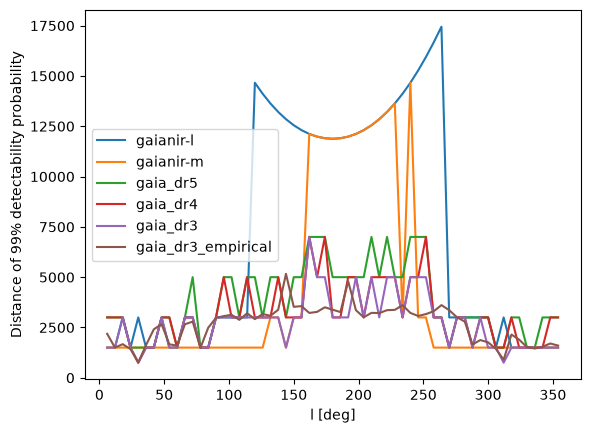

In [41]:
for m in detectabilities:
    plt.plot(l_values, detectabilities[m], label=m)

plt.gca().set(xlabel="l [deg]", ylabel=r"Distance of 99% detectability probability")
plt.legend()

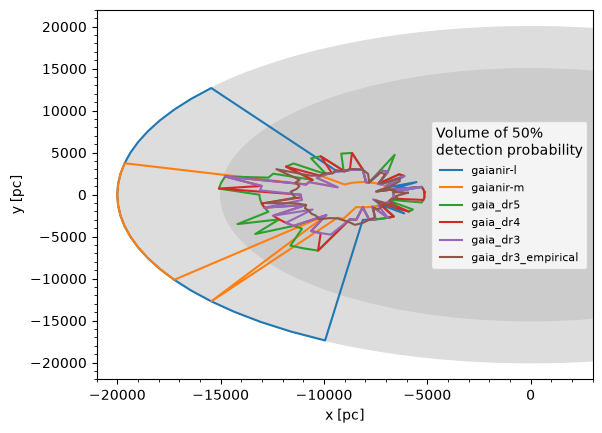

In [42]:
for m in detectabilities:
    coord = SkyCoord(
        l=np.asarray(l_values) * u.deg,
        b=np.zeros_like(l_values) * u.deg,
        distance=np.asarray(detectabilities[m]) * u.pc,
        frame="galactic"
    ).transform_to("galactocentric").represent_as("cartesian")
    x_values = coord.x.value
    y_values = coord.y.value
    x_values = np.append(x_values, x_values[0])
    y_values = np.append(y_values, y_values[0])
    plt.plot(x_values, y_values, label=m)

# xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()

plt.gca().add_patch(plt.Circle((0, 0), radius=20000, color="#ddd"))
plt.gca().add_patch(plt.Circle((0, 0), radius=15000, color="#ccc"))

# plt.gca().set(xlim=xlim, ylim=ylim)

plt.gca().set(xlabel="x [pc]", ylabel="y [pc]", xlim=(-21000, 3000))
plt.legend(title=f"Volume of {test_probability:.0%}\ndetection probability", fontsize=8)
plt.gca().minorticks_on()

## Aside: how to measure density

In [619]:
l = 90
d = 2000
cl = "ic_2602"


region_name = f"{l:.3f}_0.000"
region = pd.read_parquet(RESULTS_DIRECTORY / f"regions/{region_name}.parquet")
region = add_gaia_dr3_uncertainties_based_on_sampling(region)


with open(RESULTS_DIRECTORY / f"regions/{region_name}_metadata.pickle", 'rb') as file:
    region_metadata = pickle.load(file)

In [620]:
members = pd.read_parquet(
    RESULTS_DIRECTORY / f"clusters/{cl}/{region_name}_{d:.3f}.parquet"
)
members = add_gaia_dr3_uncertainties_based_on_sampling(members)

In [621]:
members['gaianir-l'].sum(), members['gaianir-m'].sum(), members['gaia_dr5'].sum()

(np.int64(397), np.int64(376), np.int64(79))

In [622]:
region['n-k'] = region['gaianir_n'] - region['gaianir_k']
members['n-k'] = members['gaianir_n'] - members['gaianir_k']

In [623]:
info = simulated_clusters_full.query(f"cluster=='{cl}' and l=={l} and distance=={d}").iloc[0]

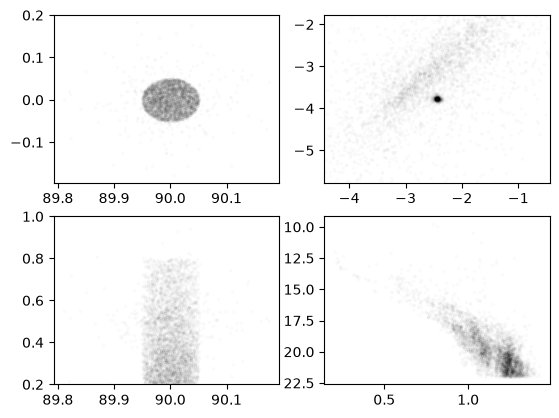

In [645]:
region_good = region.query(
    f"`uncrowded_gaianir-l` and gaianir_n < 22 and `parallax_gaianir-l` < {info['parallax'] + 0.3} and `parallax_gaianir-l` > {info['parallax']-0.3}"
)
members_good = members.query("`gaianir-l` and gaianir_n < 22").rename(
    columns={"parallax_gaianir-l_combined": "parallax_gaianir-l"}
)

fig, ax = plt.subplots(nrows=2, ncols=2)
ax = ax.flatten()

x_labels = ["l", "pmra_gaianir-l_combined", "l", "n-k"]
y_labels = ["b", "pmdec_gaianir-l_combined", "parallax_gaianir-l", "gaianir_n"]
for i, (x_label, y_label) in enumerate(zip(x_labels, y_labels)):
    ax[i].scatter(
        region_good[x_label], region_good[y_label], color="k", s=3, alpha=0.01
    )
    ax[i].scatter(
        members_good[x_label], members_good[y_label], color="k", s=3, alpha=0.01
    )

ax[1].set(
    xlim=(info["pmra"] - 2, info["pmra"] + 2),
    ylim=(info["pmdec"] - 2, info["pmdec"] + 2),
)
ax[2].set(ylim=(info["parallax"] - 0.3, info["parallax"] + 0.5))
ax[3].invert_yaxis()

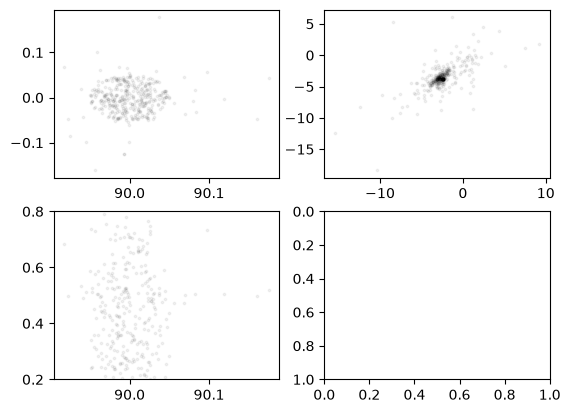

In [657]:
region_good = region.query(
    f"`uncrowded_gaia` and gaia_dr3_g < 20 and parallax_gaia_dr5 < {info['parallax'] + 0.3} and parallax_gaia_dr5 > {info['parallax']-0.3}"
)
members_good = members.query("gaia_dr5 and g_effective_gaia < 20")
fig, ax = plt.subplots(nrows=2, ncols=2)
ax = ax.flatten()

x_labels = ["l", "pmra_gaia_dr3", "l"]
y_labels = ["b", "pmdec_gaia_dr3", "parallax_gaia_dr3"]
for i, (x_label, y_label) in enumerate(zip(x_labels, y_labels)):
    ax[i].scatter(region_good[x_label], region_good[y_label], color="k", s=3, alpha=0.05)
    ax[i].scatter(
        members_good[x_label], members_good[y_label], color="k", s=3, alpha=0.05
    )

# ax[1].set(
#     xlim=(info["pmra"] - 1, info["pmra"] + 1),
#     ylim=(info["pmdec"] - 1, info["pmdec"] + 1),
# )
ax[2].set(ylim=(info["parallax"] - 0.3, info["parallax"] + 0.3))
ax[3].invert_yaxis()

In [666]:
m = "gaianir-l"
(
    info[f"rho_data_pm_{m}"],
    info[f"rho_position_{m}"] / info[f"n_stars_{m}"],
    info[f"rho_pm_{m}"] / info[f"n_stars_{m}"],
    info[f"rho_parallax_{m}"] / info[f"n_stars_{m}"],
)

(np.float64(13023.11084987215),
 np.float64(71.06369285195068),
 np.float64(93.16977436930424),
 np.float64(4.51841192351458))

In [667]:
info[f"n_stars_{m}"]

np.int64(391)

In [668]:
info[f"rho_pm_{m}"]

np.float64(36429.381778397954)

In [672]:
radius_angular = np.degrees(np.arctan(info['r_tidal'] / info['distance']))

peak_density = info[f"rho_astrometric_{m}"]
data_density = info[f"rho_data_pm_{m}"] * np.pi * radius_angular**2

print(peak_density, data_density)

print((peak_density + data_density) / data_density)

151095.73234237023 2719.7503375804213
56.55500085967079


In [670]:
peak_density = info[f"rho_position_{m}"]
data_density = info[f"rho_data_position_{m}"]

print(peak_density, data_density)

print((peak_density + data_density) / data_density)

27785.903905112715 547487.4
1.0507516773995398


In [ ]:
# peak_density = (
#     info[f"rho_position_{m}"]
#     * info[f"rho_pm_{m}"]
#     * info[f"rho_parallax_{m}"]
#     / info[f"n_stars_{m}"] ** 2
# )
# data_density = info[f"rho_data_pm_{m}"]

# print(peak_density, data_density)

# print((peak_density + data_density) / data_density)

In [ ]:
# peak_density = info[f"rho_full_{m}"]
# data_density = info[f"rho_data_pm_{m}"]

# print(peak_density, data_density)

# print((peak_density + data_density) / data_density)

In [602]:
info['probability_gaia_dr3_empirical']

np.float64(0.0033613773994147778)

In [499]:
info[f"rho_position_{m}"]

np.float64(11309.920821351056)

In [379]:
info[f'n_stars_for_rho_data_{m}'] / region_area

np.float64(1086342.0)